# Preprocessing


---
## 0 · Environment Setup

In [25]:
import sys
from pathlib import Path

PROJECT_ROOT = Path().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f"Project root: {PROJECT_ROOT}")
print(f"Python: {sys.version.split()[0]}")

Project root: D:\Coding\Code Projects\DisasterSight
Python: 3.12.1


In [26]:
import csv
import json
import math
import time
from collections import Counter, defaultdict

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
from PIL import Image
from tqdm.notebook import tqdm

from src.common.paths import get_path_map, load_config
from src.data.crop_extraction import (
    assign_event_splits,
    create_masked_crop,
    extract_crop,
    extract_crops_for_scene,
    get_extraction_config,
    load_scene_metadata,
    load_wildfire_scenes,
    normalise_disaster_type,
    normalise_label,
    pad_and_clamp_bbox,
    parse_wkt_polygon,
    polygon_area_pixels,
    polygon_to_bbox,
)

---
## 1 · Configuration

In [27]:
cfg = load_config()
path_map = get_path_map(cfg)
ext_cfg = get_extraction_config()

XBD_ROOT        = path_map["xbd_root"]
INTERIM_DIR     = path_map["interim_data_dir"]
CROPS_ROOT      = ext_cfg["crops_root"]
TARGET_SIZE     = ext_cfg["target_size"]
PADDING         = ext_cfg["padding"]
MIN_AREA        = ext_cfg["min_area_pixels"]
SEED            = ext_cfg["seed"]
TRAIN_FRAC      = ext_cfg["train_frac"]
VAL_FRAC        = ext_cfg["val_frac"]

INTERIM_DIR.mkdir(parents=True, exist_ok=True)
CROPS_ROOT.mkdir(parents=True, exist_ok=True)

print(f"xBD root      : {XBD_ROOT}")
print(f"Crops output  : {CROPS_ROOT}")
print(f"Metadata out  : {INTERIM_DIR}")
print(f"Target size   : {TARGET_SIZE}px")
print(f"Padding       : {PADDING}px")
print(f"Min area      : {MIN_AREA}px²")
print(f"Seed          : {SEED}")
print(f"Train/val frac: {TRAIN_FRAC}/{VAL_FRAC}")

xBD root      : D:\Coding\Code Projects\DisasterSight\data\raw\xbd
Crops output  : D:\Coding\Code Projects\DisasterSight\data\interim\crops
Metadata out  : D:\Coding\Code Projects\DisasterSight\data\interim
Target size   : 224px
Padding       : 12px
Min area      : 32.0px²
Seed          : 42
Train/val frac: 0.7/0.15


---
## 2 · Scene Index

Load the wildfire-only scene index. Disaster metadata
(name, type) is then attached from each scene's post-disaster JSON.

In [28]:
complete_scenes = load_wildfire_scenes(XBD_ROOT)
print(f" {len(complete_scenes):,} wildfire scenes")

 4,592 wildfire scenes


In [29]:
# Attach disaster metadata to each complete scene record
print("Loading per-scene disaster metadata")
for rec in tqdm(complete_scenes.values(), desc="Metadata"):
    meta = load_scene_metadata(rec["post_json"])
    rec["disaster_name"] = meta.get("disaster", rec["scene_id"])
    rec["disaster_type_raw"] = meta.get("disaster_type", "unknown")
    rec["disaster_type"] = normalise_disaster_type(rec["disaster_type_raw"])


Loading per-scene disaster metadata


Metadata:   0%|          | 0/4592 [00:00<?, ?it/s]

In [30]:
# Scene counts per event
event_counts = Counter(rec["disaster_name"] for rec in complete_scenes.values())
type_counts  = Counter(rec["disaster_type"] for rec in complete_scenes.values())

print("\nComplete scenes per event:")
for ev, n in sorted(event_counts.items()):
    dtype = next(r["disaster_type"] for r in complete_scenes.values() if r["disaster_name"] == ev)
    print(f"  {ev:<30}  {n:>4} scenes  [{dtype}]")

print("\nComplete scenes per disaster type:")
for dt, n in sorted(type_counts.items()):
    print(f"  {dt:<15} {n:>4}")


Complete scenes per event:
  pinery-bushfire                 1845 scenes  [wildfire]
  portugal-wildfire               1869 scenes  [wildfire]
  woolsey-fire                     878 scenes  [wildfire]

Complete scenes per disaster type:
  wildfire        4592


---
## 3 · Dataset splits

All scenes from the same disaster event are assigned the same split

In [31]:
event_names = list(event_counts.keys())
split_map = assign_event_splits(event_names, seed=SEED, train_frac=TRAIN_FRAC, val_frac=VAL_FRAC)

print("Split:")
for ev, sp in sorted(split_map.items()):
    n = event_counts[ev]
    print(f"  {sp:<6}  {ev:<30}  ({n} scenes)")

# Attach split to each scene record
for rec in complete_scenes.values():
    rec["split"] = split_map.get(rec["disaster_name"], "train")

split_scene_counts = Counter(rec["split"] for rec in complete_scenes.values())
print("\nScene totals by split:")
for sp in ("train", "val", "test"):
    print(f"  {sp:<6} {split_scene_counts[sp]:>5} scenes")

Split:
  val     pinery-bushfire                 (1845 scenes)
  train   portugal-wildfire               (1869 scenes)
  test    woolsey-fire                    (878 scenes)

Scene totals by split:
  train   1869 scenes
  val     1845 scenes
  test     878 scenes


---
## 4 · CHeck output

Before running full extraction, verify the on one scene and visualise

In [32]:
# Pick a scene with a reasonable number of annotated buildings
# (note: probably choose woolsey-fire shown below)
DRY_RUN_SCENE = "woolsey-fire_00000000"

if DRY_RUN_SCENE not in complete_scenes:
    for sid, rec in complete_scenes.items():
        from src.data.crop_extraction import extract_building_features
        if len(extract_building_features(rec["post_json"])) >= 3:
            DRY_RUN_SCENE = sid
            break

dry_rec = complete_scenes[DRY_RUN_SCENE]
print(f"Dry-run scene : {DRY_RUN_SCENE}")
print(f"Disaster : {dry_rec['disaster_name']} [{dry_rec['disaster_type']}]")
print(f"Split   : {dry_rec['split']}")
print(f"Pre  image  : {dry_rec['pre_image'].name}")
print(f"Post image    : {dry_rec['post_image'].name}")

Dry-run scene : woolsey-fire_00000000
Disaster : woolsey-fire [wildfire]
Split   : test
Pre  image  : woolsey-fire_00000000_pre_disaster.png
Post image    : woolsey-fire_00000000_post_disaster.png


In [33]:
from src.data.crop_extraction import extract_building_features

dry_features = extract_building_features(dry_rec["post_json"])
print(f"Total features in JSON : {len(dry_features)}")

# Parse each polygon and show basic stats
valid_polys = []
skipped = 0
for feat in dry_features:
    props = feat.get("properties") or {}
    ftype = str(props.get("feature_type", "")).strip().lower()
    if ftype and ftype != "building":
        skipped += 1
        continue
    pts = parse_wkt_polygon(feat.get("wkt", ""))
    if not pts:
        skipped += 1
        continue
    area = polygon_area_pixels(pts)
    label = normalise_label(props.get("subtype") or props.get("damage"))
    valid_polys.append({"pts": pts, "area": area, "label": label, "uid": props.get("uid", "")})

print(f"Valid building polygons: {len(valid_polys)}")
print(f"Skipped (non-building /no WKT): {skipped}")
print(f"Passing min-area filter ({MIN_AREA}px²) : {sum(1 for p in valid_polys if p['area'] >= MIN_AREA)}")

label_counts = Counter(p["label"] for p in valid_polys)
print("\nLabel distribution:")
for lbl, cnt in sorted(label_counts.items()):
    print(f"  {lbl:<15} {cnt}")

Total features in JSON : 3
Valid building polygons : 3
Skipped (non-building / no WKT) : 0
Passing min-area filter (32.0px²) : 3

Label distribution:
  destroyed       3


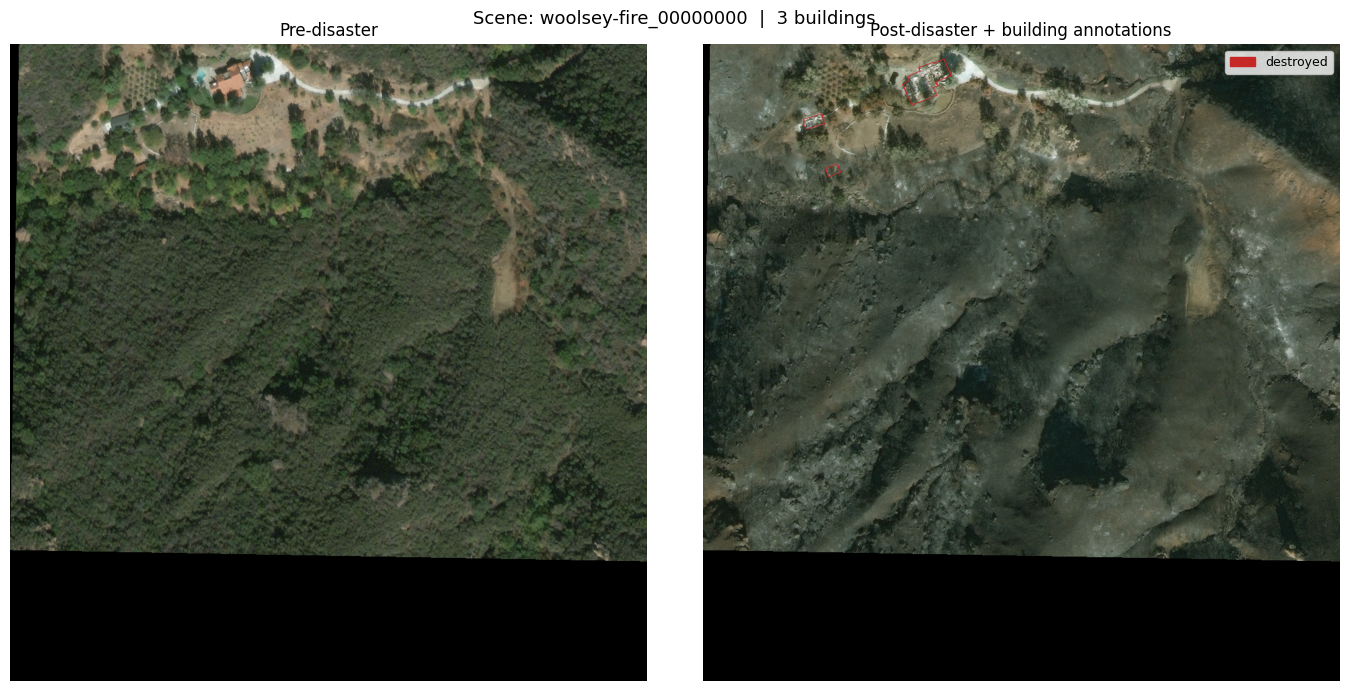

In [ ]:
# Visualise polygon overlays on the post-disaster image
LABEL_COLORS = {
    "no_damage": "#4CAF50",
    "minor_damage": "#FFC107",
    "major_damage":"#FF7043",
    "destroyed":  "#C62828",
    "unclassified": "#9E9E9E",
    "unknown":  "#9E9E9E",
}

post_img= Image.open(dry_rec["post_image"]).convert("RGB")
pre_img= Image.open(dry_rec["pre_image"]).convert("RGB")

from PIL import ImageDraw, ImageFont
annotated = post_img.copy()
draw = ImageDraw.Draw(annotated)

for poly_info in valid_polys:
    pts = poly_info["pts"]
    color = LABEL_COLORS.get(poly_info["label"], "#9E9E9E")
    if len(pts) >= 3:
        draw.polygon(pts, outline=color, width=2)

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
axes[0].imshow(pre_img)
axes[0].set_title("Pre-disaster", fontsize=12)
axes[0].axis("off")
axes[1].imshow(annotated)
axes[1].set_title("Post-disaster + building annotations", fontsize=12)
axes[1].axis("off")

# Legend
patches = [mpatches.Patch(color=c, label=l) for l, c in LABEL_COLORS.items() if l in label_counts]
axes[1].legend(handles=patches, loc="upper right", fontsize=9, framealpha=0.8)

fig.suptitle(f"Scene: {DRY_RUN_SCENE}  |  {len(valid_polys)} buildings", fontsize=13)
plt.tight_layout()
plt.show()

In [11]:
# Run extraction on the single dry-run scene and display sample crops
DRY_RUN_CROPS_DIR = CROPS_ROOT.parent / "crops_dryrun"
DRY_RUN_CROPS_DIR.mkdir(parents=True, exist_ok=True)

dry_records = extract_crops_for_scene(
    dry_rec,
    crops_root=DRY_RUN_CROPS_DIR,
    split=dry_rec["split"],
    target_size=TARGET_SIZE,
    padding=PADDING,
    min_area_pixels=MIN_AREA,
    save_masked=True,
)

print(f"Extracted {len(dry_records)} building crops from {DRY_RUN_SCENE}")
print(f"Saved to : {DRY_RUN_CROPS_DIR / DRY_RUN_SCENE}")

dr_labels = Counter(r["damage_label"] for r in dry_records)
print("Label distribution in crops:")
for lbl, cnt in sorted(dr_labels.items()):
    print(f"  {lbl:<15} {cnt}")

Extracted 3 building crops from woolsey-fire_00000000
Saved to : D:\Coding\Code Projects\DisasterSight\data\interim\crops_dryrun\woolsey-fire_00000000
Label distribution in crops:
  destroyed       3


---
## 5 · Sample Crop Grid
Visualise a grid of paired pre/post crops

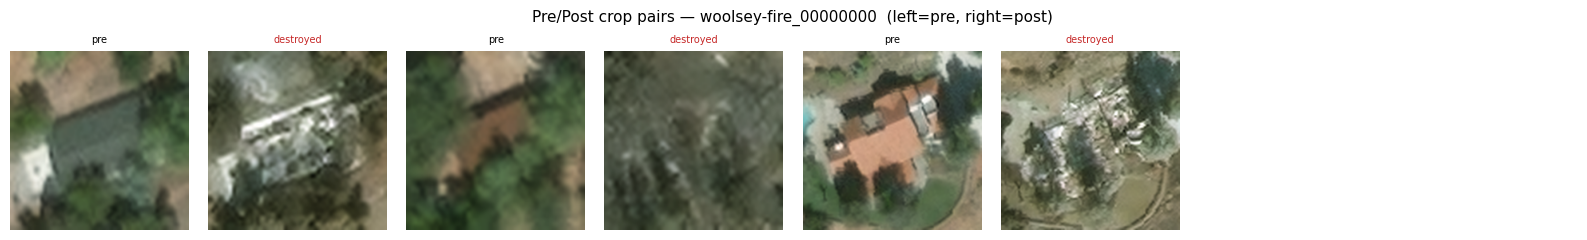

In [ ]:
def show_crop_grid(records: list[dict], n_cols: int = 4, max_rows: int = 3, title: str = "") -> None:
    """Display a grid of pre/post crop pairs with damage labels."""
    # Sample evenly across damage classes
    by_label: dict[str, list] = defaultdict(list)
    for r in records:
        by_label[r["damage_label"]].append(r)

    sampled = []
    per_label = max(1, (n_cols * max_rows) // max(len(by_label), 1))
    for lbl in sorted(by_label):
        sampled.extend(by_label[lbl][:per_label])
    sampled = sampled[: n_cols * max_rows]

    if not sampled:
        print("No records to display.")
        return

    n_rows = math.ceil(len(sampled) / n_cols)
    fig, axes = plt.subplots(n_rows, n_cols * 2, figsize=(n_cols * 4, n_rows * 2.4))
    axes = np.array(axes).reshape(n_rows, n_cols * 2)

    for idx, rec in enumerate(sampled):
        row, col_pair = divmod(idx, n_cols)
        pre_ax  = axes[row, col_pair * 2]
        post_ax = axes[row, col_pair * 2 + 1]

        pre_path  = PROJECT_ROOT / rec["pre_crop_path"]
        post_path = PROJECT_ROOT / rec["post_crop_path"]

        if pre_path.exists():
            pre_ax.imshow(Image.open(pre_path))
        pre_ax.set_title("pre", fontsize=7)
        pre_ax.axis("off")

        if post_path.exists():
            post_ax.imshow(Image.open(post_path))
        lbl = rec["damage_label"]
        color = LABEL_COLORS.get(lbl, "gray")
        post_ax.set_title(f"{lbl}", fontsize=7, color=color)
        post_ax.axis("off")

    #hide unused axes
    for idx in range(len(sampled), n_rows * n_cols):
        row, col_pair = divmod(idx, n_cols)
        axes[row, col_pair * 2].axis("off")
        axes[row, col_pair * 2 + 1].axis("off")

    if title:
        fig.suptitle(title, fontsize=11)
    plt.tight_layout()
    plt.show()


show_crop_grid(
    dry_records,
    n_cols=4,
    max_rows=3,
    title=f"Pre/Post crop pairs — {DRY_RUN_SCENE}  (left=pre, right=post)",
)

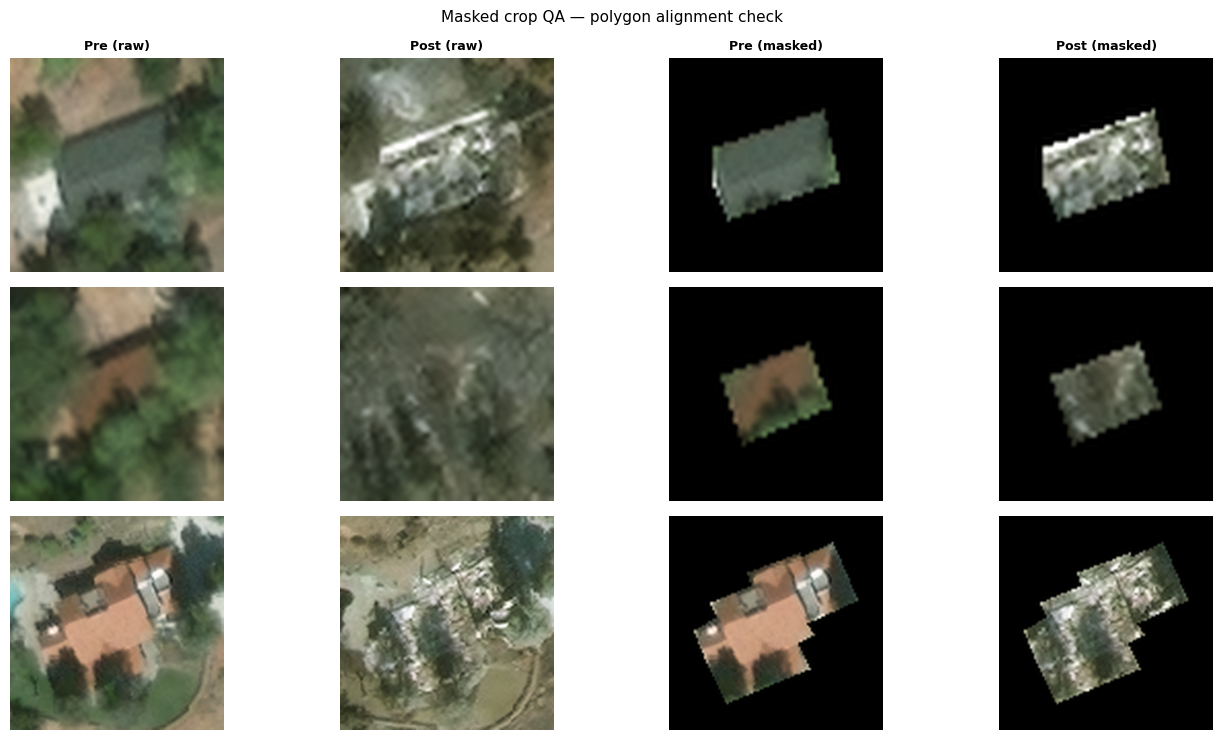

In [ ]:
# visualise masked crops for a few buildings (debug check on polygon alignment)
masked_records = [r for r in dry_records if r.get("pre_masked_crop_path")]

if masked_records:
    n_show = min(6, len(masked_records))
    fig, axes = plt.subplots(n_show, 4, figsize=(14, n_show * 2.5))
    if n_show == 1:
        axes = axes[np.newaxis, :]

    col_labels = ["Pre (raw)", "Post (raw)", "Pre (masked)", "Post (masked)"]
    for ax, lbl in zip(axes[0], col_labels):
        ax.set_title(lbl, fontsize=9, fontweight="bold")

    for i, rec in enumerate(masked_records[:n_show]):
        paths = [
            PROJECT_ROOT/ rec["pre_crop_path"],
            PROJECT_ROOT/ rec["post_crop_path"],
            PROJECT_ROOT/ rec["pre_masked_crop_path"],
            PROJECT_ROOT/ rec["post_masked_crop_path"],
        ]
        for j, p in enumerate(paths):
            ax = axes[i, j]
            if p.exists():
                ax.imshow(Image.open(p))
            ax.axis("off")
        axes[i, 0].set_ylabel(rec["damage_label"], fontsize=8, rotation=0, labelpad=55)

    fig.suptitle("Masked crop QA — polygon alignment check", fontsize=11)
    plt.tight_layout()
    plt.show()
else:
    print("No masked crops found (save_masked=True required in dry run).")

---
## 6 · Full Extraction

Extract crops from all complete wildfire scenes. Failed scenes loggged.

In [ ]:
# Configuration for the full run
SAVE_MASKED_FULL = False

print(f"Output directory : {CROPS_ROOT}")
print(f"Scenes to process: {len(complete_scenes):,}")
print(f"Save masked crops: {SAVE_MASKED_FULL}")
print("\nStarting extraction …")

Output directory : D:\Coding\Code Projects\DisasterSight\data\interim\crops
Scenes to process: 4,592
Save masked crops: False

Starting extraction …


In [15]:
all_crop_records: list[dict] = []
failed_scenes: list[tuple[str, str]] = []

t_start = time.time()

for scene_id, rec in tqdm(complete_scenes.items(), desc="Extracting crops", unit="scene"):
    try:
        records = extract_crops_for_scene(
            rec,
            crops_root=CROPS_ROOT,
            split=rec["split"],
            target_size=TARGET_SIZE,
            padding=PADDING,
            min_area_pixels=MIN_AREA,
            save_masked=SAVE_MASKED_FULL,
        )
        all_crop_records.extend(records)
    except Exception as exc:
        failed_scenes.append((scene_id, str(exc)))

elapsed = time.time() - t_start
print(f"\nDone in {elapsed:.1f}s")
print(f"Total crops extracted : {len(all_crop_records):,}")
print(f"Failed scenes         : {len(failed_scenes)}")

if failed_scenes:
    print("\nFailed scenes:")
    for sid, err in failed_scenes:
        print(f"  {sid}: {err}")

Extracting crops:   0%|          | 0/4592 [00:00<?, ?scene/s]


Done in 1012.4s
Total crops extracted : 35,925
Failed scenes         : 0


---
## 7 · Write Crop Metadata CSV & Parquet

In [16]:
METADATA_CSV  = INTERIM_DIR / "crop_metadata.csv"
METADATA_PARQUET = INTERIM_DIR / "crop_metadata.parquet"

# Build DataFrame
df = pd.DataFrame(all_crop_records)

# Enforce column order matching the interface contract
COLUMN_ORDER = [
    "building_id", "scene_id", "disaster_name", "disaster_type", "split",
    "damage_label", "polygon_wkt",
    "bbox_x1", "bbox_y1", "bbox_x2", "bbox_y2",
    "area_pixels", "crop_width", "crop_height",
    "pre_crop_path", "post_crop_path",
    "pre_masked_crop_path", "post_masked_crop_path",
]
df = df[[c for c in COLUMN_ORDER if c in df.columns]]

# Save
df.to_csv(METADATA_CSV, index=False)
print(f"Saved CSV     → {METADATA_CSV}")
print(f"  Rows: {len(df):,}  Columns: {len(df.columns)}")

try:
    df.to_parquet(METADATA_PARQUET, index=False)
    print(f"Saved Parquet → {METADATA_PARQUET}")
except Exception as e:
    print(f"Parquet save skipped ({e}) — CSV is sufficient.")

Saved CSV     → D:\Coding\Code Projects\DisasterSight\data\interim\crop_metadata.csv
  Rows: 35,925  Columns: 18
Saved Parquet → D:\Coding\Code Projects\DisasterSight\data\interim\crop_metadata.parquet


In [17]:
# Preview the metadata table
df.head(8)

,building_id,scene_id,disaster_name,disaster_type,split,damage_label,polygon_wkt,bbox_x1,bbox_y1,bbox_x2,bbox_y2,area_pixels,crop_width,crop_height,pre_crop_path,post_crop_path,pre_masked_crop_path,post_masked_crop_path
0,141f11ee-4a5f-46ef-9baf-1f432ece6fd5,pinery-bushfire_00000001,pinery-bushfire,wildfire,val,unclassified,"POLYGON ((177.9312910793614 744.3347554433644,...",162,732,198,766,78.52,36,34,data\interim\crops\pinery-bushfire_00000001\14...,data\interim\crops\pinery-bushfire_00000001\14...,,
1,3ef34719-e22b-4f9e-b890-69e627d033ce,pinery-bushfire_00000002,pinery-bushfire,wildfire,val,no_damage,"POLYGON ((28.21014662453097 276.5345601154199,...",16,221,67,290,991.02,51,69,data\interim\crops\pinery-bushfire_00000002\3e...,data\interim\crops\pinery-bushfire_00000002\3e...,,
2,78a32643-5072-4435-8de8-0d7091294fc7,pinery-bushfire_00000002,pinery-bushfire,wildfire,val,no_damage,"POLYGON ((33.02721081007211 308.5365902308525,...",14,287,49,321,74.84,35,34,data\interim\crops\pinery-bushfire_00000002\78...,data\interim\crops\pinery-bushfire_00000002\78...,,
3,7620aecc-eec3-4198-9cfb-f0730dba4d77,pinery-bushfire_00000002,pinery-bushfire,wildfire,val,no_damage,"POLYGON ((67.20048305407184 301.5039035198155,...",53,289,94,329,207.31,41,40,data\interim\crops\pinery-bushfire_00000002\76...,data\interim\crops\pinery-bushfire_00000002\76...,,
4,05236880-d03d-4fd4-a8ad-cb4287232f55,pinery-bushfire_00000002,pinery-bushfire,wildfire,val,no_damage,"POLYGON ((49.4796170676481 355.3226580798425, ...",26,340,62,377,101.57,36,37,data\interim\crops\pinery-bushfire_00000002\05...,data\interim\crops\pinery-bushfire_00000002\05...,,
5,28d7b3a5-ecba-4eca-87c7-cfc2399cfc75,pinery-bushfire_00000002,pinery-bushfire,wildfire,val,no_damage,"POLYGON ((299.9832680063607 569.3464360932044,...",287,552,325,589,101.43,38,37,data\interim\crops\pinery-bushfire_00000002\28...,data\interim\crops\pinery-bushfire_00000002\28...,,
6,d1ef1981-e9d9-4bf0-add7-2f7b963cf659,pinery-bushfire_00000002,pinery-bushfire,wildfire,val,no_damage,"POLYGON ((93.19477169177543 11.58125609077966,...",74,0,106,36,66.91,32,36,data\interim\crops\pinery-bushfire_00000002\d1...,data\interim\crops\pinery-bushfire_00000002\d1...,,
7,800e6fff-c965-4300-ba80-36ce4992912e,pinery-bushfire_00000002,pinery-bushfire,wildfire,val,unclassified,POLYGON ((-2.298323030769493e-06 538.932488735...,0,526,19,569,104.43,19,43,data\interim\crops\pinery-bushfire_00000002\80...,data\interim\crops\pinery-bushfire_00000002\80...,,
